In [40]:
import numpy as np
import matplotlib.pyplot as plt

import wavefunctions

In [2]:
def minimum_image_displacement(r_i, r_j, lattice):
    """
    Returns the minimum-image displacement r_i - r_j under PBC
    for a general lattice cell.

    Assumes lattice is a (dim, dim) matrix whose columns are the
    lattice vectors in Cartesian coordinates.

    If your computeLattice returns rows instead of columns, you may
    need to transpose lattice here.
    """
    lattice_inv = np.linalg.inv(lattice)
    s = lattice_inv @ (r_i - r_j)
    s -= np.round(s)
    dr = lattice @ s
    return dr

(1, 1024, 56, 2)
(32,) (32,)
(32,) (32,)
--------------------
(1024, 56, 2)


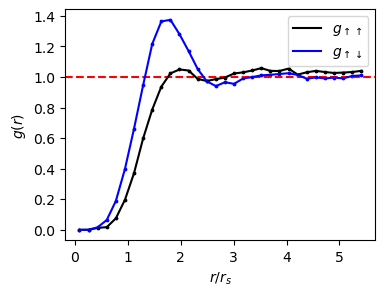

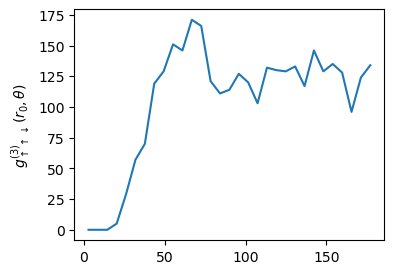

In [97]:


def compute_gr(rs, lattice, spins, spin0, spin1, r_max=None, n_bins=32):
    """
    Computes the total pair correlation function g(r) from an array
    of configurations rs with shape (slices, walkers, N, dim).

    Returns:
        r_centers : bin centers
        g_r       : estimated pair correlation function
    """
    def get_spin_range(i):
        if i == 0:
            return range(spins[0])
        elif i == 1:
            return range(spins[0],spins[0]+spins[1])
        else:
            raise Exception("INVALID SPIN")
    
    (n_slices, n_walkers, N, dim) = rs.shape

    cell_area = abs(np.linalg.det(lattice))

    if r_max is None:
        # Defaults to half of shortest lattice vector
        lattice_vec_lengths = [np.linalg.norm(lattice[:, i]) for i in range(dim)]
        r_max = 0.5 * min(lattice_vec_lengths)

    # `np.linspace` uses bounds inclusively
    bin_edges = np.linspace(0.0, r_max, n_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    dr_bin = bin_edges[1] - bin_edges[0]

    hist = np.zeros(n_bins, dtype=float)

    n_pairs = 0.0

    for s in range(n_slices):
        for w in range(n_walkers):
            config = rs[s, w]
            for i in get_spin_range(spin0):
                for j in get_spin_range(spin1):
                    if i == j:
                        continue;
                    n_pairs += 1.0
                    dr = minimum_image_displacement(config[i], config[j], lattice)
                    r = np.linalg.norm(dr)
                    if r < r_max:
                        bin_index = int(r / dr_bin)
                        hist[bin_index] += 1.0

    shell_areas = 2.0 * np.pi * bin_centers * dr_bin
    
    # The first normalization underpredicts the same-spin electron correlation
    #   function since it counts the i=i pair in the normalization
    # The second normalization counts the actual number of valid distinct pairs
    
    #n_configs = n_slices * n_walkers
    #density = (N/2) / cell_area
    #normalization = n_configs * (N/2) * density * shell_areas
    normalization = n_pairs * shell_areas / cell_area
    
    g_r = hist / normalization
    
    return bin_centers, g_r

N = 56
dim = 2
r_ws = 20

spins = (N//2,N//2)
lattice = wavefunctions.computeLattice(
    N, r_ws, dim, basis_matrix=np.array([[7,0],[0,4*np.sqrt(3)]])
)

#rs = np.concatenate([
#        np.random.uniform(high=lattice[0,0], size=(500,1024,N,1)),
#        np.random.uniform(high=lattice[1,1], size=(500,1024,N,1))
#    ], axis=-1
#)
rs = np.load("data/2body.npy")
#rs = np.load("data/Nbody.npy")

(slices,walkers,_,_) = rs.shape
local_rs = rs[0:1] # rs[0:20:5]

"""
bin_centers_same, g_r_same = compute_gr(
    local_rs, lattice, spins, 0, 0, r_max=5.5*r_ws, n_bins=32
)
bin_centers_diff, g_r_diff = compute_gr(
    local_rs, lattice, spins, 0, 1, r_max=5.5*r_ws, n_bins=32
)
"""

print(local_rs.shape)
print(bin_centers_same.shape, g_r_same.shape)
print(bin_centers_diff.shape, g_r_diff.shape)

print("--------------------")

def get_spin_range(i):
    if i == 0:
        return range(spins[0])
    elif i == 1:
        return range(spins[0],spins[0]+spins[1])
    else:
        raise Exception("INVALID SPIN")

def in_range(val, val_range):
    return val > val_range[0] and val < val_range[1]

target_r = bin_centers_same[10]
dr = bin_centers_same[1] - bin_centers_same[0]

r_range = ( target_r - dr/2 , target_r + dr/2 )
config = rs[100,0]

(spin0,spin1,spin2) = (0,0,1)

theta_bin_edges = np.linspace(0.0, np.pi, 32)
theta_bin_centers = 0.5 * (theta_bin_edges[:-1] + theta_bin_edges[1:])
theta_bin_counts = np.zeros(theta_bin_centers.shape)

print(rs[0].shape)

for config in rs[0]:
    for i in get_spin_range(spin0):
        for j in get_spin_range(spin1):
            for k in get_spin_range(spin2):
                
                if i == j or j == k or i == k:
                    continue;
                    
                dr_ij = minimum_image_displacement(config[i], config[j], lattice)
                dr_ik = minimum_image_displacement(config[i], config[k], lattice)
                dr_jk = minimum_image_displacement(config[j], config[k], lattice)
    
                if not (in_range(np.linalg.norm(dr_ij), r_range) and in_range(np.linalg.norm(dr_ik), r_range)):
                    continue;
    
                theta = np.arccos(np.dot(dr_ij, dr_ik) / (np.linalg.norm(dr_ij) * np.linalg.norm(dr_ik)))
                bin_idx = np.argmin((theta_bin_centers - theta)**2.0)

                if spin1 == spin2:
                    r_bin_centers = bin_centers_same
                    g_r = g_r_same
                else:
                    r_bin_centers = bin_centers_diff
                    g_r = g_r_diff
                
                r_idx = np.argmin((np.linalg.norm(dr_jk) - r_bin_centers)**2.0)
                theta_bin_counts[bin_idx] += 1 # / g_r[r_idx]

plt.figure(figsize=(4,3))

plt.axhline(y=1.0, color='red', linestyle='--')
plt.plot(
    bin_centers_same / r_ws, g_r_same,
    color='black', label=r"$g_{\uparrow\uparrow}$"
)
plt.scatter(
    bin_centers_same / r_ws, g_r_same,
    color='black', s=3
)
#plt.axhline(y=np.mean(g_r_same), color='black', linestyle='--')

plt.plot(
    bin_centers_diff / r_ws, g_r_diff,
    color='blue', label=r"$g_{\uparrow\downarrow}$"
)
plt.scatter(
    bin_centers_diff / r_ws, g_r_diff,
    color='blue', s=3
)
#plt.axhline(y=np.mean(g_r_diff), color='blue', linestyle='--')

plt.legend()
plt.xlabel(r"$r / r_s$")
plt.ylabel(r"$g(r)$")
plt.show()

plt.figure(figsize=(4,3))
plt.plot(theta_bin_centers * 180 / np.pi, theta_bin_counts)
plt.ylabel(r"$g^{(3)}_{\uparrow \uparrow \downarrow}(r_0, \theta)$")
plt.show()